In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [4]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [5]:
sbx = sb.query("index <= '2024-03-31 23:59:59'")
sbx.shape, sb.shape

((1238, 10), (3640, 10))

In [6]:
# define X and Y
sby = sb.query("index > '2024-03-31 23:59:59'")
sby.shape, sb.shape

((2402, 10), (3640, 10))

In [7]:
pred_len = abs(sbx.shape[0] - sb.shape[0])
pred_len

2402

In [8]:
node = ["43768720"]
serie_train = sbx[node]
serie_test = sby[node]

sazonalidade =  7 * 40

## Decomposition

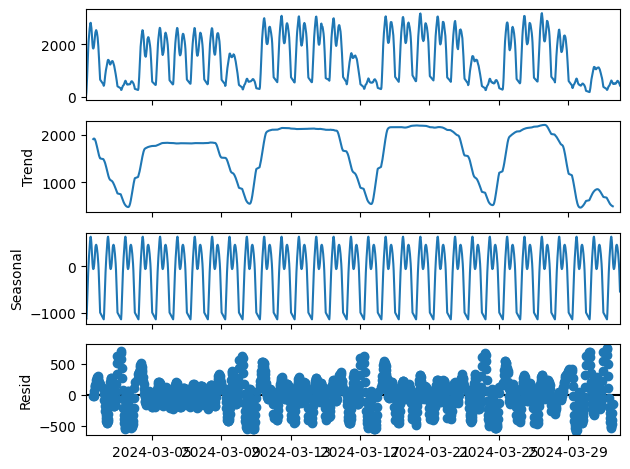

In [11]:
result = seasonal_decompose(serie_train, 
                            model='additive', 
                            period=40)
result.plot()
plt.show()

## linregress

In [30]:
serie_train[node].to_numpy().flatten().shape

(1238,)

In [32]:
x = np.arange(serie_train.shape[0])
#print(f"series node: {x.shape} - pandas: {serie_train[node].values.shape}")
slope, intercept, r_value, p_value, std_err = linregress(x, 
                                                         serie_train[node].to_numpy().flatten())

print(f"Slope: {slope:.4f} | p-value: {p_value:.4f}")

Slope: -0.1625 | p-value: 0.0160


In [34]:
# slope > 0 → tendência de alta

# slope < 0 → tendência de queda

# p-value < 0.05 → tendência estatisticamente significativa

## adfuller

In [35]:
result = adfuller(serie_train[node])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -2.2514
p-value: 0.1881


In [ ]:
📌 Se p-value > 0.05 → a série não é estacionária → pode ter tendência.